<a href="https://colab.research.google.com/github/SypherKx/SP500-Stock-Price-Prediction/blob/main/Stock_Market_Predcition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import yfinance as yf

In [7]:
sp500=yf.Ticker("^GSPC")

In [8]:
sp500_history = sp500.history(period="max")

In [10]:
sp500_history.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0


In [16]:
sp500_history.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2025-09-29 00:00:00-04:00', '2025-09-30 00:00:00-04:00',
               '2025-10-01 00:00:00-04:00', '2025-10-02 00:00:00-04:00',
               '2025-10-03 00:00:00-04:00', '2025-10-06 00:00:00-04:00',
               '2025-10-07 00:00:00-04:00', '2025-10-08 00:00:00-04:00',
               '2025-10-09 00:00:00-04:00', '2025-10-10 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24561, freq=None)

<Axes: xlabel='Date'>

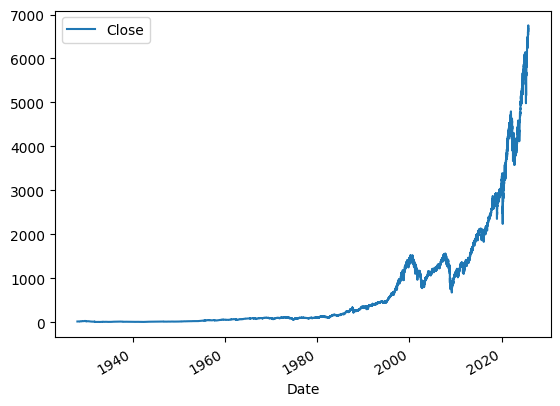

In [18]:
sp500_history.plot.line(y="Close",use_index=True)

In [19]:
del sp500_history["Dividends"]
del sp500_history["Stock Splits"]

In [21]:
sp500_history.head()

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0


In [22]:
sp500_history["Tomorrow"] = sp500_history["Close"].shift(-1)

In [23]:
sp500_history

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2025-10-06 00:00:00-04:00,6733.859863,6749.520020,6717.779785,6740.279785,5604460000,6714.589844
2025-10-07 00:00:00-04:00,6746.140137,6754.490234,6699.959961,6714.589844,5546150000,6753.720215
2025-10-08 00:00:00-04:00,6723.870117,6755.640137,6718.089844,6753.720215,5383130000,6735.109863


In [24]:
sp500_history["Target"]=(sp500_history["Tomorrow"]>sp500_history["Close"]).astype(int)

In [25]:
sp500_history

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2025-10-06 00:00:00-04:00,6733.859863,6749.520020,6717.779785,6740.279785,5604460000,6714.589844,0
2025-10-07 00:00:00-04:00,6746.140137,6754.490234,6699.959961,6714.589844,5546150000,6753.720215,1
2025-10-08 00:00:00-04:00,6723.870117,6755.640137,6718.089844,6753.720215,5383130000,6735.109863,0


In [26]:
sp500_history=sp500_history.loc["1990-01-01":].copy()

In [27]:
sp500_history

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2025-10-06 00:00:00-04:00,6733.859863,6749.520020,6717.779785,6740.279785,5604460000,6714.589844,0
2025-10-07 00:00:00-04:00,6746.140137,6754.490234,6699.959961,6714.589844,5546150000,6753.720215,1
2025-10-08 00:00:00-04:00,6723.870117,6755.640137,6718.089844,6753.720215,5383130000,6735.109863,0


In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
 model=RandomForestClassifier(n_estimators=100,min_samples_split=100,random_state=1)

In [36]:
train = sp500_history.iloc[:-100]
test = sp500_history.iloc[-100:]

predictor=["Close","Volume","Open","High","Low"]
model.fit(train[predictor],train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [47]:
from sklearn.metrics import precision_score
preds=model.predict(test[predictor])

In [48]:
import pandas as pd
preds=pd.Series(preds,index=test.index)

In [49]:
preds

,0
Date,
2025-05-20 00:00:00-04:00,1
2025-05-21 00:00:00-04:00,1
2025-05-22 00:00:00-04:00,1
2025-05-23 00:00:00-04:00,1
2025-05-27 00:00:00-04:00,1
...,...
2025-10-06 00:00:00-04:00,0
2025-10-07 00:00:00-04:00,0
2025-10-08 00:00:00-04:00,0


In [50]:
precision_score(test["Target"],preds)

0.5217391304347826

In [57]:
combined=pd.concat([test["Target"],preds],axis=1)

<Axes: xlabel='Date'>

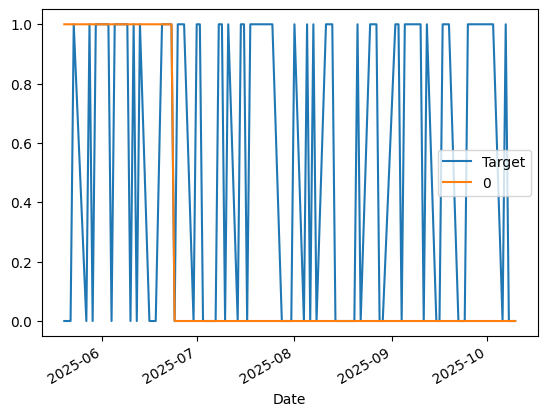

In [58]:
combined.plot()


In [64]:
def predict(train,test,predictor,model):
    model.fit(train[predictor],train["Target"])
    preds=model.predict(test[predictor])
    preds=pd.Series(preds,index=test.index,name="Predictions")
    combined =pd.concat([test["Target"],preds],axis=1)
    return combined

In [63]:
def backtest(data,model,predictors,start=2500,step=250):
    all_predictions =[]

    for i in range(start,data.shape[0],step):
        train_ = data.iloc[0:i].copy()
        test_ = data.iloc[i:(i+step)].copy()
        predictions = predict(train_,test_,predictors,model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

In [66]:
predictions = backtest(sp500_history,model,predictor)

In [67]:
predictions["Predictions"].value_counts()

,count
Predictions,
0,3845
1,2666


In [69]:
precision_score(predictions["Target"],predictions["Predictions"])

0.5300075018754689

In [71]:
predictions["Target"].value_counts()/predictions.shape[0]

,count
Target,
1,0.536937
0,0.463063


In [74]:
horizon=[2,5,60,250,1000]
new_predictors=[]

for horizon in horizon:
  rolling_averages=sp500_history.rolling(horizon).mean()
  ratio_column=f"Close_Ratio_{horizon}"
  sp500_history[ratio_column]=sp500_history["Close"]/rolling_averages["Close"]

  trend_column=f"Trend_{horizon}"
  sp500_history[trend_column]=sp500_history.shift(1).rolling(horizon).sum()["Target"]
  new_predictors+=[ratio_column,trend_column]

In [78]:
sp500_history

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Close_Ratio_5,Close_Ratio_60,Close_Ratio_250,Close_Ratio_1000,Trend_2,Trend_5,Trend_60,Trend_250,Trend_1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,0.993731,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-06 00:00:00-04:00,6733.859863,6749.520020,6717.779785,6740.279785,5604460000,6714.589844,0,1.001820,1.003882,1.041522,1.121499,1.381509,2.0,5.0,36.0,143.0,533.0
2025-10-07 00:00:00-04:00,6746.140137,6754.490234,6699.959961,6714.589844,5546150000,6753.720215,1,0.998091,0.999278,1.036362,1.116467,1.375577,1.0,4.0,35.0,143.0,533.0
2025-10-08 00:00:00-04:00,6723.870117,6755.640137,6718.089844,6753.720215,5383130000,6735.109863,0,1.002905,1.003831,1.041035,1.122225,1.382916,1.0,4.0,36.0,143.0,533.0


In [79]:
sp500_history=sp500_history.dropna()

In [80]:
model=RandomForestClassifier(n_estimators=200,min_samples_split=50,random_state=1)

In [86]:
def predict(train,test,predictor,model):
    model.fit(train[predictor],train["Target"])
    preds=model.predict_proba(test[predictor])[:,1]
    preds[preds >= .6]=1
    preds[preds < .6]=0
    preds=pd.Series(preds,index=test.index,name="Predictions")
    combined =pd.concat([test["Target"],preds],axis=1)
    return combined

In [87]:
predictions=backtest(sp500_history,model,new_predictors)

In [88]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,4639
1.0,871


In [89]:
precision_score(predictions["Target"],predictions["Predictions"])

0.5717566016073479